In [19]:
# ================================================================
# Cell 1: Environment Setup for HST CAL FITS Dataset
# ================================================================

!pip install -q astropy astroscrappy scipy scikit-image tqdm matplotlib pandas


In [20]:
# ================================================================
# Cell 2: Imports
# ================================================================

import os
import gc
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy import ndimage
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from astropy.io import fits
import astroscrappy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [21]:
# ================================================================
# Cell 3: Dataset Path Setup
# ================================================================
# Your local zip has this structure:
# dataset/CAL/MAST_2026-04-29T1538/HST/*_cal.fits
#
# On Kaggle, upload dataset.zip as a Kaggle dataset.
# Kaggle usually places it somewhere under /kaggle/input/.

KAGGLE_INPUT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")
EXTRACT_DIR = WORKING_DIR / "hst_cal_dataset"
OUTPUT_DIR = WORKING_DIR / "cleaned_fits"
CHECKPOINT_DIR = WORKING_DIR / "checkpoints"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def find_dataset_zip():
    """
    Find dataset.zip inside /kaggle/input.

    Returns:
        Path | None: Path to dataset.zip if found.
    """
    matches = list(KAGGLE_INPUT.rglob("dataset.zip"))
    if matches:
        return matches[0]
    return None

zip_path = find_dataset_zip()

if zip_path is not None:
    print("Found zip:", zip_path)
    if not EXTRACT_DIR.exists():
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(EXTRACT_DIR)
    DATA_ROOT = EXTRACT_DIR
else:
    print("No dataset.zip found. Checking for already extracted FITS files.")
    DATA_ROOT = KAGGLE_INPUT

fits_files = sorted(DATA_ROOT.rglob("*_cal.fits"))

print("Data root:", DATA_ROOT)
print("Number of HST CAL FITS files:", len(fits_files))
print("Example files:")
for path in fits_files[:5]:
    print(" ", path)


No dataset.zip found. Checking for already extracted FITS files.
Data root: /kaggle/input
Number of HST CAL FITS files: 330
Example files:
  /kaggle/input/datasets/madhuswapnika2/hst-dataset/dataset/CAL/MAST_2026-04-29T1538/HST/n3zb45d7q_cal.fits
  /kaggle/input/datasets/madhuswapnika2/hst-dataset/dataset/CAL/MAST_2026-04-29T1538/HST/n3zb45d8q_cal.fits
  /kaggle/input/datasets/madhuswapnika2/hst-dataset/dataset/CAL/MAST_2026-04-29T1538/HST/n48r01k1q_cal.fits
  /kaggle/input/datasets/madhuswapnika2/hst-dataset/dataset/CAL/MAST_2026-04-29T1538/HST/n48r01k2q_cal.fits
  /kaggle/input/datasets/madhuswapnika2/hst-dataset/dataset/CAL/MAST_2026-04-29T1538/HST/n48r01k3q_cal.fits


In [22]:
# ================================================================
# Cell 4: HST CAL FITS Reader
# ================================================================

def read_hst_cal_fits(path):
    """
    Read one HST calibrated FITS image.

    This function is intentionally defensive because HST products may store
    science arrays in PRIMARY, SCI, IMAGE, or another 2D HDU depending on
    instrument and processing generation.

    Args:
        path (str | Path): Path to an HST *_cal.fits file.

    Returns:
        tuple:
            image (np.ndarray): 2D float32 science image.
            header (fits.Header): FITS header from selected HDU.
            hdu_name (str): Name of selected HDU.
    """
    path = Path(path)

    with fits.open(path, memmap=False) as hdul:
        preferred_names = ["SCI", "PRIMARY", "IMAGE"]

        for preferred_name in preferred_names:
            for hdu in hdul:
                if hdu.name.upper() == preferred_name and hdu.data is not None:
                    data = np.asarray(hdu.data)
                    if data.ndim >= 2:
                        image = np.squeeze(data).astype(np.float32)

                        # If a FITS HDU contains a cube, take the first image plane.
                        while image.ndim > 2:
                            image = image[0]

                        return image, hdu.header, hdu.name

        # Fallback: first numeric 2D HDU.
        for hdu in hdul:
            if hdu.data is not None:
                data = np.asarray(hdu.data)
                if data.ndim >= 2 and np.issubdtype(data.dtype, np.number):
                    image = np.squeeze(data).astype(np.float32)
                    while image.ndim > 2:
                        image = image[0]
                    return image, hdu.header, hdu.name

    raise ValueError(f"No usable 2D science image found in {path}")


In [23]:
# ================================================================
# Cell 5: Normalization + L.A.Cosmic Pseudo Labels
# ================================================================

def percentile_normalize(image, low=1, high=99):
    """
    Robustly normalize an astronomical image to [0, 1].

    Cosmic rays are extreme outliers, so min-max normalization is a bad idea.
    Percentile normalization keeps stars and background visible.

    Args:
        image (np.ndarray): Raw science image.
        low (float): Lower percentile.
        high (float): Upper percentile.

    Returns:
        tuple[np.ndarray, dict]: Normalized image and scaling metadata.
    """
    finite = np.isfinite(image)

    if finite.mean() < 0.5:
        raise ValueError("Too many non-finite pixels in FITS image.")

    fill_value = np.nanmedian(image[finite])
    safe = np.where(finite, image, fill_value)

    p_low, p_high = np.percentile(safe[finite], [low, high])
    scale = max(p_high - p_low, 1e-6)

    normalized = np.clip((safe - p_low) / scale, 0, 1).astype(np.float32)

    meta = {
        "p_low": float(p_low),
        "p_high": float(p_high),
        "scale": float(scale),
    }

    return normalized, meta


def lacosmic_pseudo_label(image, filename=None):
    """
    Generate a pseudo cosmic ray mask using L.A.Cosmic, then slightly dilate
    detected CR regions with a 3x3 morphological kernel.
    """
    try:
        cr_mask, clean_image = astroscrappy.detect_cosmics(
            image.astype(np.float32),
            sigclip=3.5,
            sigfrac=0.5,
            objlim=3.0,
            gain=1.0,
            readnoise=6.5,
            satlevel=np.inf,
            niter=4,
            sepmed=True,
            cleantype="medmask",
        )

        if not np.any(cr_mask):
            name = filename if filename is not None else "unknown file"
            print(f"Warning: no cosmic rays detected in {name}")

        # Expand detected CR regions slightly with a 3x3 kernel.
        cr_mask = ndimage.binary_dilation(
            cr_mask.astype(bool),
            structure=np.ones((3, 3), dtype=bool),
        )

        return cr_mask.astype(np.float32), clean_image.astype(np.float32)

    except Exception as e:
        name = filename if filename is not None else "unknown file"
        print(f"L.A.Cosmic failed for {name}, using empty mask: {e}")
        return np.zeros_like(image, dtype=np.float32), image.copy()


def inject_synthetic_cosmic_rays(clean_image, probability=0.5):
    """
    Add synthetic cosmic rays to real HST backgrounds.

    This improves training because L.A.Cosmic pseudo labels can miss faint
    events and may be conservative.

    Args:
        clean_image (np.ndarray): Clean or pseudo-clean image in [0, 1].
        probability (float): Probability of injection.

    Returns:
        tuple[np.ndarray, np.ndarray]:
            contaminated image and synthetic mask.
    """
    image = clean_image.copy()
    mask = np.zeros_like(image, dtype=np.float32)

    if random.random() > probability:
        return image, mask

    height, width = image.shape
    num_events = random.randint(1, 8)

    for _ in range(num_events):
        y0 = random.randint(0, height - 1)
        x0 = random.randint(0, width - 1)
        length = random.randint(5, 60)
        angle = random.uniform(0, np.pi)
        intensity = random.uniform(0.35, 1.0)
        thickness = random.choice([1, 1, 2])

        for step in range(length):
            y = int(round(y0 + step * np.sin(angle)))
            x = int(round(x0 + step * np.cos(angle)))

            if 0 <= y < height and 0 <= x < width:
                y1 = max(0, y - thickness)
                y2 = min(height, y + thickness + 1)
                x1 = max(0, x - thickness)
                x2 = min(width, x + thickness + 1)

                mask[y1:y2, x1:x2] = 1.0
                image[y1:y2, x1:x2] = np.clip(image[y1:y2, x1:x2] + intensity, 0, 1)

    return image.astype(np.float32), mask.astype(np.float32)


In [24]:
# ================================================================
# Cell 6: PyTorch Dataset for HST CAL FITS Files
# ================================================================

class HSTCosmicRayDataset(Dataset):
    """
    Patch dataset for your HST *_cal.fits files.

    It creates training samples using:
    1. Real HST image patches.
    2. L.A.Cosmic pseudo masks.
    3. Optional synthetic cosmic rays for stronger supervised learning.

    Returns:
        image: Contaminated image patch.
        mask: Cosmic ray mask.
        target: Clean target image.
    """

    def __init__(
        self,
        fits_files,
        patch_size=256,
        patches_per_file=8,
        use_synthetic=True,
        synthetic_probability=0.5,
        augment=False,
    ):
        self.fits_files = list(fits_files)
        self.patch_size = patch_size
        self.patches_per_file = patches_per_file
        self.use_synthetic = use_synthetic
        self.synthetic_probability = synthetic_probability
        self.augment = augment

        self.index = []

        for file_idx, path in enumerate(tqdm(self.fits_files, desc="Indexing FITS files")):
            try:
                image, _, _ = read_hst_cal_fits(path)
                height, width = image.shape

                if height < patch_size or width < patch_size:
                    continue

                for _ in range(patches_per_file):
                    y = random.randint(0, height - patch_size)
                    x = random.randint(0, width - patch_size)
                    self.index.append((file_idx, y, x))

            except Exception as e:
                print(f"Skipping {path.name}: {e}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        file_idx, y, x = self.index[idx]
        path = self.fits_files[file_idx]

        try:
            raw_image, _, _ = read_hst_cal_fits(path)
            image, norm_meta = percentile_normalize(raw_image)

            patch = image[y:y+self.patch_size, x:x+self.patch_size]

            pseudo_mask, pseudo_clean = lacosmic_pseudo_label(patch, filename=path.name)

            if self.use_synthetic:
                synthetic_input, synthetic_mask = inject_synthetic_cosmic_rays(
                    pseudo_clean,
                    probability=self.synthetic_probability,
                )

                final_image = synthetic_input
                final_mask = np.maximum(pseudo_mask, synthetic_mask).astype(np.float32)
                final_target = pseudo_clean.astype(np.float32)
            else:
                final_image = patch.astype(np.float32)
                final_mask = pseudo_mask.astype(np.float32)
                final_target = pseudo_clean.astype(np.float32)

            if self.augment:
                if random.random() < 0.5:
                    final_image = np.fliplr(final_image)
                    final_mask = np.fliplr(final_mask)
                    final_target = np.fliplr(final_target)

                if random.random() < 0.5:
                    final_image = np.flipud(final_image)
                    final_mask = np.flipud(final_mask)
                    final_target = np.flipud(final_target)

                k = random.randint(0, 3)
                if k > 0:
                    final_image = np.rot90(final_image, k)
                    final_mask = np.rot90(final_mask, k)
                    final_target = np.rot90(final_target, k)

                noise = np.random.normal(0.0, 0.01, size=final_image.shape).astype(np.float32)
                final_image = np.clip(final_image + noise, 0.0, 1.0)

            final_image = np.ascontiguousarray(final_image, dtype=np.float32)
            final_mask = np.ascontiguousarray(final_mask, dtype=np.float32)
            final_target = np.ascontiguousarray(final_target, dtype=np.float32)

            return {
                "image": torch.from_numpy(final_image[None]).float(),
                "mask": torch.from_numpy(final_mask[None]).float(),
                "target": torch.from_numpy(final_target[None]).float(),
                "path": str(path),
            }

        except Exception as e:
            print(f"Error loading {path.name}: {e}")

            zero = torch.zeros(1, self.patch_size, self.patch_size)

            return {
                "image": zero,
                "mask": zero,
                "target": zero,
                "path": str(path),
            }


In [25]:
# ================================================================
# Cell 7: DataLoaders
# ================================================================

PATCH_SIZE = 256
BATCH_SIZE = 4
PATCHES_PER_FILE = 8

dataset = HSTCosmicRayDataset(
    fits_files=fits_files,
    patch_size=PATCH_SIZE,
    patches_per_file=PATCHES_PER_FILE,
    use_synthetic=True,
    synthetic_probability=0.5,
)

print("Total patches:", len(dataset))

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
    persistent_workers=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

test_loader = DataLoader(
    test_ds,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)


print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Indexing FITS files:   0%|          | 0/330 [00:00<?, ?it/s]

Total patches: 2640
Train batches: 528
Val batches: 66
Test batches: 264


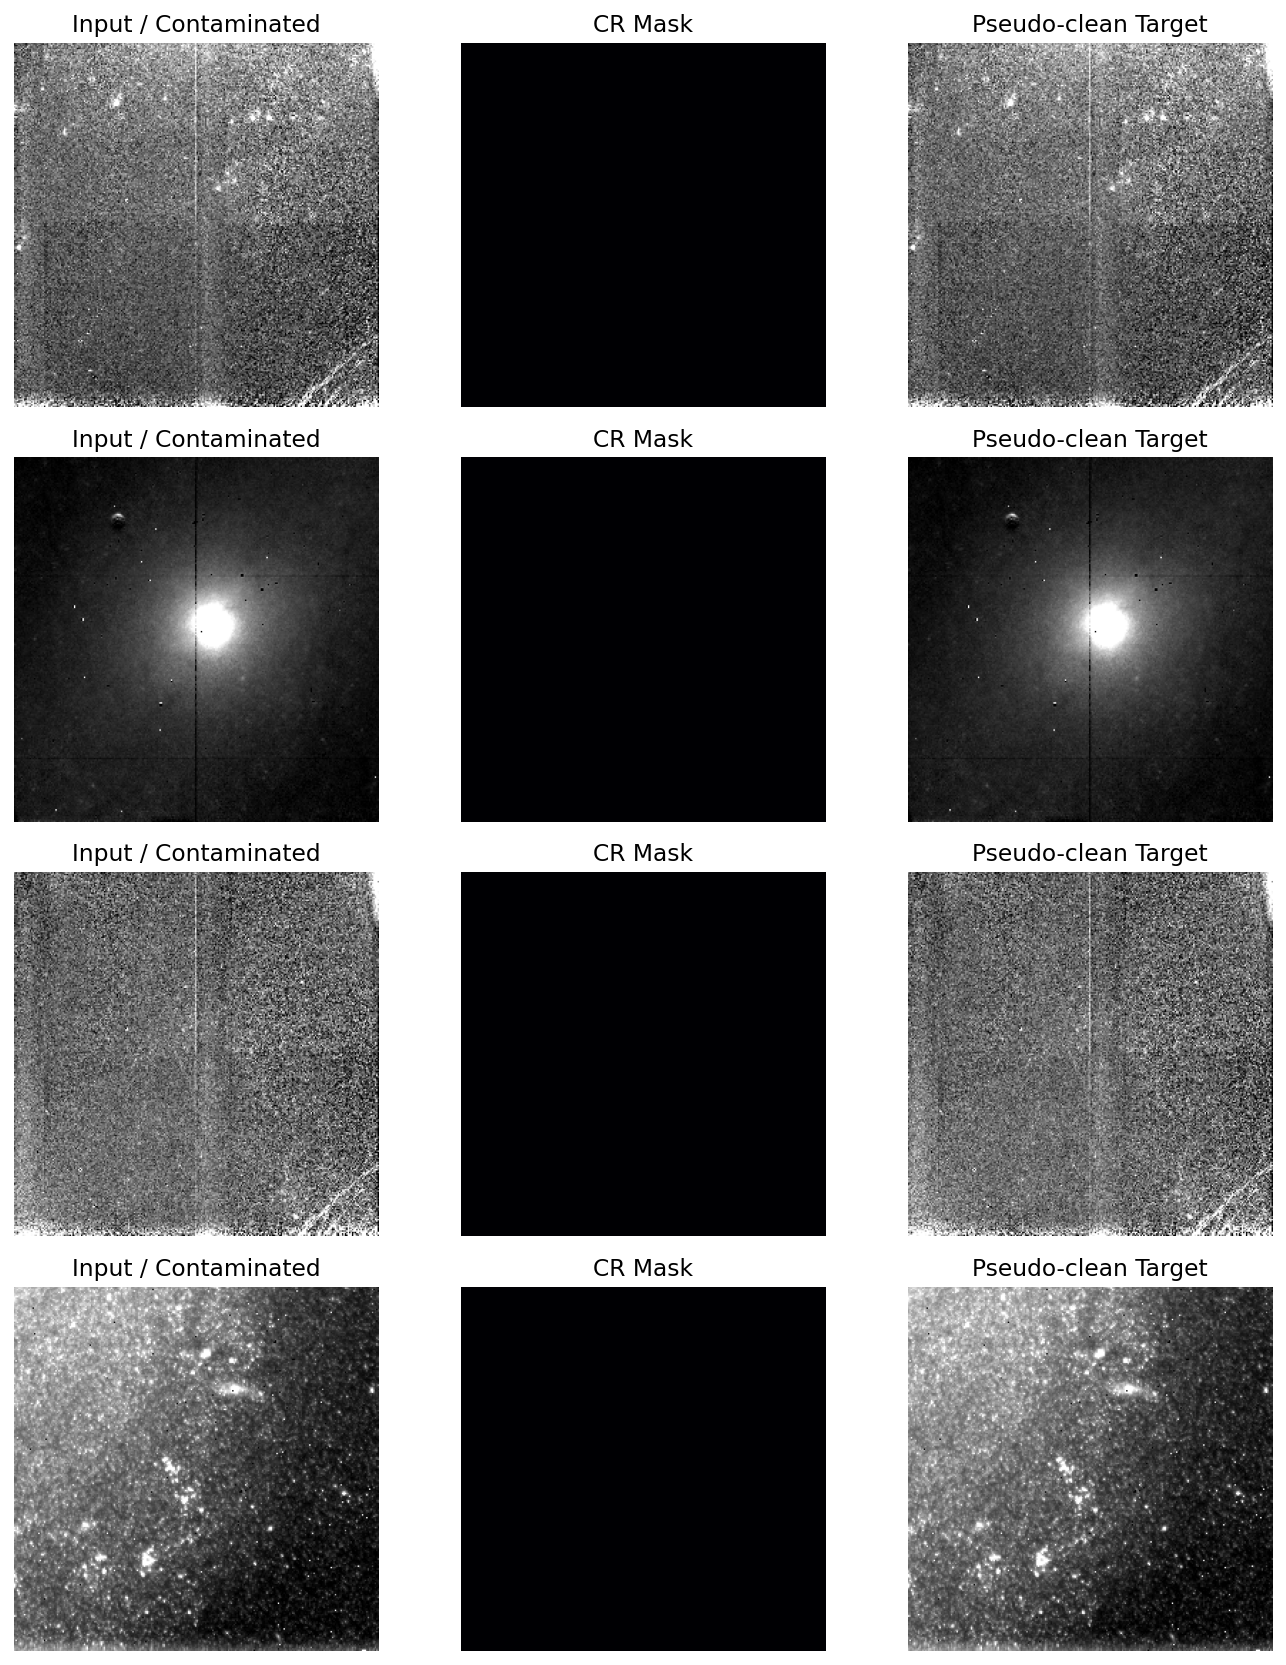

Example file: /kaggle/input/datasets/madhuswapnika2/hst-dataset/dataset/CAL/MAST_2026-04-29T1538/HST/n48r02esq_cal.fits
Image range: 0.0 1.0
Mask positive fraction: 0.0


In [26]:
# ================================================================
# Cell 8: Visualize Dataset Samples
# ================================================================

batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]
targets = batch["target"]

num_show = min(4, images.shape[0])

fig, axes = plt.subplots(num_show, 3, figsize=(10, 3 * num_show), dpi=140)

for i in range(num_show):
    axes[i, 0].imshow(images[i, 0], cmap="gray", origin="lower")
    axes[i, 0].set_title("Input / Contaminated")

    axes[i, 1].imshow(masks[i, 0], cmap="magma", origin="lower")
    axes[i, 1].set_title("CR Mask")

    axes[i, 2].imshow(targets[i, 0], cmap="gray", origin="lower")
    axes[i, 2].set_title("Pseudo-clean Target")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

print("Example file:", batch["path"][0])
print("Image range:", images.min().item(), images.max().item())
print("Mask positive fraction:", masks.mean().item())


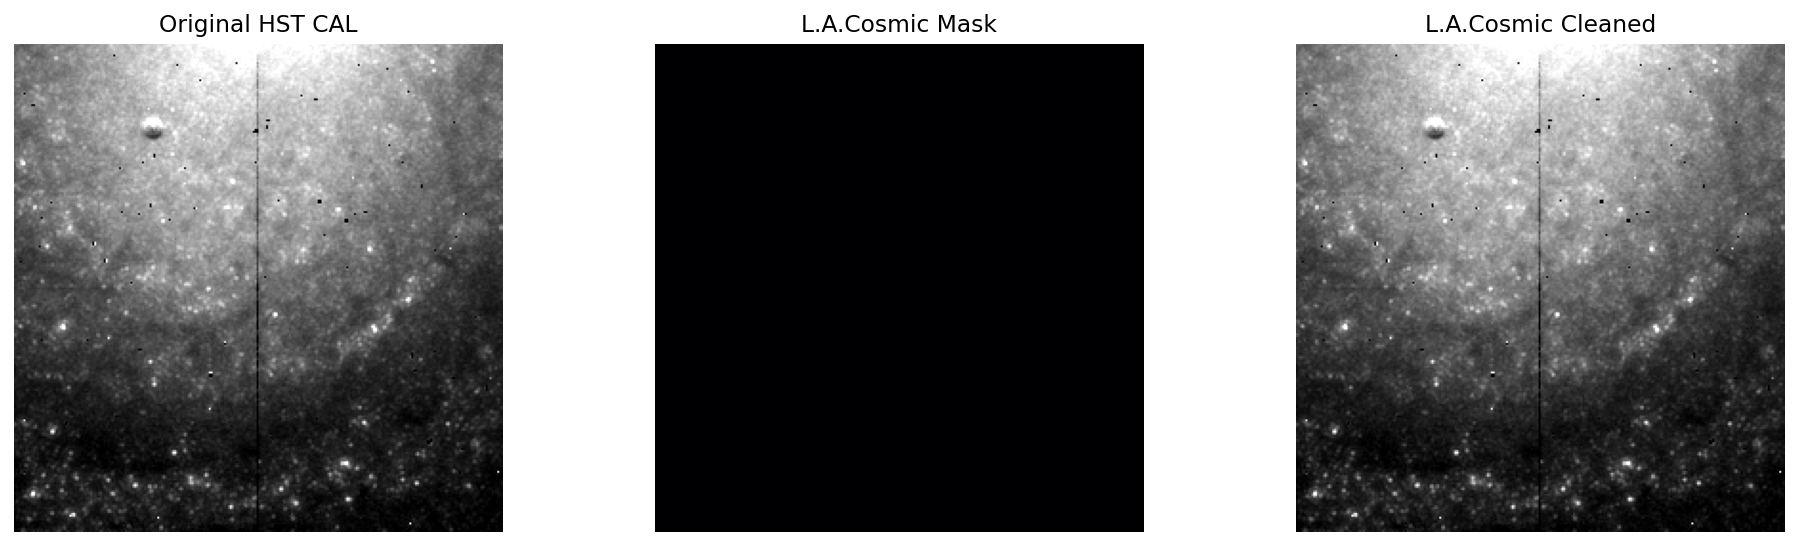

File: n3zb45d7q_cal.fits
Selected HDU: SCI
Mask fraction: 0.0


In [27]:
# ================================================================
# Cell 9: Run L.A.Cosmic Baseline on One Dataset Image
# ================================================================

sample_path = fits_files[0]
raw_image, header, hdu_name = read_hst_cal_fits(sample_path)
image, norm_meta = percentile_normalize(raw_image)

cr_mask, clean_image = lacosmic_pseudo_label(image)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=140)

axes[0].imshow(image, cmap="gray", origin="lower")
axes[0].set_title("Original HST CAL")

axes[1].imshow(cr_mask, cmap="magma", origin="lower")
axes[1].set_title("L.A.Cosmic Mask")

axes[2].imshow(clean_image, cmap="gray", origin="lower")
axes[2].set_title("L.A.Cosmic Cleaned")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("File:", sample_path.name)
print("Selected HDU:", hdu_name)
print("Mask fraction:", cr_mask.mean())


In [28]:
# ================================================================
# Cell 10: Save Cleaned FITS Files for Dataset
# ================================================================

def save_lacosmic_cleaned_fits(input_path, output_path):
    """
    Clean one HST CAL FITS file using L.A.Cosmic and save a new FITS file.

    Output extensions:
    PRIMARY: cleaned image in original flux scale
    CR_MASK: cosmic ray probability/binary mask
    """
    raw_image, header, hdu_name = read_hst_cal_fits(input_path)
    image, norm_meta = percentile_normalize(raw_image)

    cr_mask, clean_norm = lacosmic_pseudo_label(image)

    clean_raw = clean_norm * norm_meta["scale"] + norm_meta["p_low"]

    primary = fits.PrimaryHDU(clean_raw.astype(np.float32), header=header)
    primary.header["CRMETHOD"] = "LACOSMIC"
    primary.header["SRCFILE"] = Path(input_path).name
    primary.header["SRCHDU"] = hdu_name

    mask_hdu = fits.ImageHDU(cr_mask.astype(np.float32), name="CR_MASK")

    fits.HDUList([primary, mask_hdu]).writeto(output_path, overwrite=True)


# Clean a small demo subset first.
NUM_TO_CLEAN = 10

for path in tqdm(fits_files[:NUM_TO_CLEAN], desc="Saving cleaned FITS"):
    out_path = OUTPUT_DIR / path.name.replace("_cal.fits", "_cleaned.fits")
    save_lacosmic_cleaned_fits(path, out_path)

print("Saved cleaned files to:", OUTPUT_DIR)
print("Example outputs:")
for path in sorted(OUTPUT_DIR.glob("*.fits"))[:5]:
    print(" ", path)


Saving cleaned FITS:   0%|          | 0/10 [00:00<?, ?it/s]

Saved cleaned files to: /kaggle/working/cleaned_fits
Example outputs:
  /kaggle/working/cleaned_fits/n3zb45d7q_cleaned.fits
  /kaggle/working/cleaned_fits/n3zb45d8q_cleaned.fits
  /kaggle/working/cleaned_fits/n48r01k1q_cleaned.fits
  /kaggle/working/cleaned_fits/n48r01k2q_cleaned.fits
  /kaggle/working/cleaned_fits/n48r01k3q_cleaned.fits


In [29]:
# ================================================================
# Cell 11: Model Architecture - PSF-Aware Residual U-Net
# ================================================================

import time
import gc
import random
from contextlib import nullcontext
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from tqdm.auto import tqdm
from scipy import ndimage


# Safety defaults if this section is run without executing Cells 1-7 first.
try:
    SEED
except NameError:
    SEED = 42

try:
    DEVICE
except NameError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    WORKING_DIR
except NameError:
    WORKING_DIR = Path("/kaggle/working") if Path("/kaggle").exists() else Path.cwd()

try:
    CHECKPOINT_DIR
except NameError:
    CHECKPOINT_DIR = WORKING_DIR / "checkpoints"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.net(x)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(self.pool(x))


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels, dropout=dropout)
        self.se = SEBlock(out_channels)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return self.se(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels, dropout=dropout)
        self.se = SEBlock(out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return self.se(x)

class PSFAwareUNet(nn.Module):
    """
    Smaller PSF-aware U-Net for cosmic ray segmentation.

    Changes:
        - Starts with 32 filters by default.
        - Uses BatchNorm in convolution heads.
        - Uses additive PSF attention with a learnable weight.
        - Uses stronger dropout in the bottleneck.
    """

    def __init__(
        self,
        in_channels=1,
        base_channels=32,
        dropout=0.05,
        bottleneck_dropout=0.3,
    ):
        super().__init__()
        c = base_channels

        self.enc1 = DoubleConv(in_channels, c, dropout=dropout)
        self.enc2 = DownBlock(c, c * 2, dropout=dropout)
        self.enc3 = DownBlock(c * 2, c * 4, dropout=dropout)
        self.enc4 = DownBlock(c * 4, c * 8, dropout=dropout)

        self.bottleneck = DownBlock(c * 8, c * 16, dropout=bottleneck_dropout)

        self.up4 = UpBlock(c * 16, c * 8, c * 8, dropout=dropout)
        self.up3 = UpBlock(c * 8, c * 4, c * 4, dropout=dropout)
        self.up2 = UpBlock(c * 4, c * 2, c * 2, dropout=dropout)
        self.up1 = UpBlock(c * 2, c, c, dropout=dropout)

        self.psf_attention = nn.Sequential(
            nn.Conv2d(in_channels, c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
            nn.Conv2d(c, c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )
        self.psf_attention_weight = nn.Parameter(torch.tensor(0.1))

        self.edge_head = nn.Sequential(
            nn.Conv2d(c, c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
            nn.Conv2d(c, 1, kernel_size=1),
        )

        self.mask_head = nn.Sequential(
            nn.Conv2d(c + 1, c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
            nn.Conv2d(c, 1, kernel_size=1),
        )

    def forward(self, x):
        e1 = self.enc1(x)

        psf_features = self.psf_attention(x)
        e1 = e1 + self.psf_attention_weight * psf_features

        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        b = self.bottleneck(e4)

        d4 = self.up4(b, e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        edge_logits = self.edge_head(d1)
        mask_logits = self.mask_head(torch.cat([d1, edge_logits], dim=1))

        return mask_logits


model = PSFAwareUNet(in_channels=1, base_channels=32, dropout=0.05).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model.__class__.__name__)
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")


PSFAwareUNet
Total parameters: 7,901,399
Trainable parameters: 7,901,399


In [30]:

# ================================================================
# Cell 12: Physics-Informed Loss Functions
# ================================================================

def gaussian_kernel2d(kernel_size=9, sigma=1.6, device=DEVICE):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=device) - (kernel_size - 1) / 2
    yy, xx = torch.meshgrid(coords, coords, indexing="ij")
    kernel = torch.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    kernel = kernel / kernel.sum().clamp_min(1e-8)
    return kernel.view(1, 1, kernel_size, kernel_size)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        targets = targets.float()
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)

        dims = (1, 2, 3)
        intersection = torch.sum(probs * targets, dims)
        union = torch.sum(probs, dims) + torch.sum(targets, dims)
        dice = 1.0 - torch.mean((2.0 * intersection + self.smooth) / (union + self.smooth))
        return bce + dice


class PhysicsInformedCRLoss(nn.Module):
    """
    Combines segmentation accuracy with astronomy-motivated constraints:
    1. Dice + BCE for pixel detection.
    2. Sharpness prior: predicted CR pixels should be sharper than PSF-smoothed image.
    3. Sparse flux prior: model should not erase large fractions of astronomical flux.
    """

    def __init__(self, detection_weight=1.0, sharpness_weight=0.15, flux_weight=0.05):
        super().__init__()
        self.detection_weight = detection_weight
        self.sharpness_weight = sharpness_weight
        self.flux_weight = flux_weight
        self.det_loss = DiceBCELoss()

    def forward(self, logits, targets, images, psf_kernel=None):
        detection_loss = self.det_loss(logits, targets)
        probs = torch.sigmoid(logits)

        if psf_kernel is None:
            psf_kernel = gaussian_kernel2d(device=images.device)

        pad = psf_kernel.shape[-1] // 2
        smooth = F.conv2d(images, psf_kernel, padding=pad)
        high_frequency = torch.abs(images - smooth)

        # Cosmic rays are high-frequency events; reward masks that align with sharp residuals.
        sharpness_loss = torch.mean(probs * (1.0 - high_frequency.detach()))

        image_flux = torch.sum(torch.abs(images), dim=(1, 2, 3)).clamp_min(1e-6)
        predicted_removed_flux = torch.sum(probs * torch.abs(images), dim=(1, 2, 3))
        flux_loss = torch.mean(predicted_removed_flux / image_flux)

        total = (
            self.detection_weight * detection_loss
            + self.sharpness_weight * sharpness_loss
            + self.flux_weight * flux_loss
        )

        return total


loss_fn = PhysicsInformedCRLoss().to(DEVICE)
psf_kernel = gaussian_kernel2d(kernel_size=9, sigma=1.6, device=DEVICE)

print("Loss ready:", loss_fn.__class__.__name__)


Loss ready: PhysicsInformedCRLoss


In [32]:
# ================================================================
# Cell 14: Metrics, Weighted Loss, Training Loop, and Checkpointing
# ================================================================

import time
import gc
from contextlib import nullcontext
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm.auto import tqdm

try:
    DEVICE
except NameError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    WORKING_DIR
except NameError:
    WORKING_DIR = Path("/kaggle/working") if Path("/kaggle").exists() else Path.cwd()

try:
    CHECKPOINT_DIR
except NameError:
    CHECKPOINT_DIR = WORKING_DIR / "checkpoints"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def empty_cuda_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()


@torch.no_grad()
def compute_positive_class_weight(loader):
    positive_pixels = 0.0
    total_pixels = 0.0

    for batch in tqdm(loader, desc="Computing class balance"):
        masks = batch["mask"].float()
        positive_pixels += masks.sum().item()
        total_pixels += masks.numel()

    negative_pixels = total_pixels - positive_pixels

    if positive_pixels <= 0:
        print("Warning: no positive CR pixels found. Using pos_weight=1.0")
        return torch.tensor(1.0, device=DEVICE)

    pos_weight = negative_pixels / positive_pixels

    print(f"Training CR pixels: {positive_pixels:.0f}")
    print(f"Training non-CR pixels: {negative_pixels:.0f}")
    print(f"BCE positive class weight: {pos_weight:.4f}")

    return torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE)


class WeightedDiceBCELoss(nn.Module):
    def __init__(self, pos_weight, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets):
        targets = targets.float()

        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)

        dims = (1, 2, 3)
        intersection = torch.sum(probs * targets, dims)
        union = torch.sum(probs, dims) + torch.sum(targets, dims)

        dice = 1.0 - torch.mean(
            (2.0 * intersection + self.smooth) / (union + self.smooth)
        )

        return bce + dice


class WeightedPhysicsInformedCRLoss(nn.Module):
    def __init__(
        self,
        pos_weight,
        detection_weight=1.0,
        sharpness_weight=0.15,
        flux_weight=0.05,
    ):
        super().__init__()
        self.detection_weight = detection_weight
        self.sharpness_weight = sharpness_weight
        self.flux_weight = flux_weight
        self.det_loss = WeightedDiceBCELoss(pos_weight=pos_weight)

    def forward(self, logits, targets, images, psf_kernel=None):
        detection_loss = self.det_loss(logits, targets)
        probs = torch.sigmoid(logits)

        if psf_kernel is None:
            psf_kernel = gaussian_kernel2d(device=images.device)

        pad = psf_kernel.shape[-1] // 2
        smooth = F.conv2d(images, psf_kernel, padding=pad)
        high_frequency = torch.abs(images - smooth)

        sharpness_loss = torch.mean(probs * (1.0 - high_frequency.detach()))

        image_flux = torch.sum(torch.abs(images), dim=(1, 2, 3)).clamp_min(1e-6)
        predicted_removed_flux = torch.sum(probs * torch.abs(images), dim=(1, 2, 3))
        flux_loss = torch.mean(predicted_removed_flux / image_flux)

        return (
            self.detection_weight * detection_loss
            + self.sharpness_weight * sharpness_loss
            + self.flux_weight * flux_loss
        )


@torch.no_grad()
def segmentation_metrics_from_logits(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    masks = masks.float()

    pred_sum = preds.sum().item()
    true_sum = masks.sum().item()

    tp = torch.sum(preds * masks).item()
    fp = torch.sum(preds * (1.0 - masks)).item()
    fn = torch.sum((1.0 - preds) * masks).item()
    tn = torch.sum((1.0 - preds) * (1.0 - masks)).item()

    total = tp + fp + fn + tn
    accuracy = (tp + tn) / total if total > 0 else np.nan

    if pred_sum == 0 and true_sum == 0:
        return {
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "iou": np.nan,
            "accuracy": 1.0,
            "true_positive_rate": np.nan,
            "false_positive_rate": 0.0,
        }

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    if np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0:
        f1 = np.nan
    else:
        f1 = 2.0 * precision * recall / (precision + recall)

    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else np.nan
    true_positive_rate = recall
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "accuracy": accuracy,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
    }


def combine_metric_sums(metric_sums, batch_metrics):
    for key, value in batch_metrics.items():
        if not np.isnan(value):
            metric_sums[key] += value
            metric_sums[f"{key}_count"] += 1


def average_metric_sums(metric_sums):
    result = {}

    metric_names = [
        "precision",
        "recall",
        "f1",
        "iou",
        "accuracy",
        "true_positive_rate",
        "false_positive_rate",
    ]

    for key in metric_names:
        count = metric_sums.get(f"{key}_count", 0)
        result[key] = metric_sums[key] / count if count > 0 else np.nan

    return result


def train_one_epoch(model, loader, optimizer, loss_fn, scaler=None, threshold=0.5):
    model.train()
    running_loss = 0.0
    metric_sums = defaultdict(float)

    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True).float()
        masks = batch["mask"].to(DEVICE, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)

        use_amp = DEVICE.type == "cuda"
        amp_context = torch.amp.autocast("cuda") if use_amp else nullcontext()

        with amp_context:
            logits = model(images)
            loss = loss_fn(logits, masks, images, psf_kernel)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        running_loss += loss.item()
        batch_metrics = segmentation_metrics_from_logits(logits.detach(), masks, threshold)
        combine_metric_sums(metric_sums, batch_metrics)

    metrics = average_metric_sums(metric_sums)
    metrics["loss"] = running_loss / max(len(loader), 1)

    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, threshold=0.5):
    model.eval()
    running_loss = 0.0
    metric_sums = defaultdict(float)

    for batch in tqdm(loader, desc="Validation", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True).float()
        masks = batch["mask"].to(DEVICE, non_blocking=True).float()

        logits = model(images)
        loss = loss_fn(logits, masks, images, psf_kernel)

        running_loss += loss.item()
        batch_metrics = segmentation_metrics_from_logits(logits, masks, threshold)
        combine_metric_sums(metric_sums, batch_metrics)

    metrics = average_metric_sums(metric_sums)
    metrics["loss"] = running_loss / max(len(loader), 1)

    return metrics


class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True

        self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return False


def train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    num_epochs=50,
    lr=1e-4,
    threshold=0.5,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-4,
):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(num_epochs, 1),
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    best_f1 = -1.0
    best_val_loss = float("inf")
    history = []

    best_path = CHECKPOINT_DIR / "best_psf_aware_unet.pth"
    last_path = CHECKPOINT_DIR / "last_psf_aware_unet.pth"

    early_stopper = EarlyStopping(
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
    )

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            scaler,
            threshold,
        )
        val_metrics = validate_one_epoch(
            model,
            val_loader,
            loss_fn,
            threshold,
        )

        scheduler.step()

        row = {
            "epoch": epoch,
            "lr": scheduler.get_last_lr()[0],
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        improved_val_loss = early_stopper.step(val_metrics["loss"])

        val_f1 = val_metrics["f1"]
        if not np.isnan(val_f1) and val_f1 > best_f1:
            best_f1 = val_f1

        if improved_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "best_f1": best_f1,
                    "best_val_loss": best_val_loss,
                    "history": history,
                    "patch_size": PATCH_SIZE,
                    "model_name": "PSFAwareUNet",
                    "pos_weight": float(loss_fn.det_loss.bce.pos_weight.item()),
                },
                best_path,
            )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "history": history,
                "patch_size": PATCH_SIZE,
                "model_name": "PSFAwareUNet",
                "pos_weight": float(loss_fn.det_loss.bce.pos_weight.item()),
            },
            last_path,
        )

        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"lr {scheduler.get_last_lr()[0]:.2e} | "
            f"train loss {train_metrics['loss']:.4f} "
            f"f1 {train_metrics['f1']:.4f} "
            f"tpr {train_metrics['true_positive_rate']:.4f} "
            f"fpr {train_metrics['false_positive_rate']:.6f} | "
            f"val loss {val_metrics['loss']:.4f} "
            f"f1 {val_metrics['f1']:.4f} "
            f"tpr {val_metrics['true_positive_rate']:.4f} "
            f"fpr {val_metrics['false_positive_rate']:.6f} | "
            f"best val loss {best_val_loss:.4f} | "
            f"early stop {early_stopper.counter}/{early_stopper.patience}"
        )

        empty_cuda_cache()

        if early_stopper.should_stop:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Validation loss did not improve for {early_stopper.patience} epochs."
            )
            break

    elapsed_min = (time.time() - start_time) / 60.0

    print(f"Training finished in {elapsed_min:.2f} minutes")
    print("Best checkpoint:", best_path)

    return pd.DataFrame(history), best_path


NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

required_training_objects = [
    "train_loader",
    "val_loader",
    "PATCH_SIZE",
    "model",
    "psf_kernel",
]

missing_training_objects = [
    name for name in required_training_objects if name not in globals()
]

if missing_training_objects:
    raise RuntimeError(
        "Before running this training cell, run the setup, dataset, dataloader, model, and loss cells first. "
        f"Missing objects: {missing_training_objects}"
    )

pos_weight = compute_positive_class_weight(train_loader)
loss_fn = WeightedPhysicsInformedCRLoss(pos_weight=pos_weight).to(DEVICE)

history_df, best_model_path = train_model(
    model,
    train_loader,
    val_loader,
    loss_fn=loss_fn,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=0.5,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
)

display(history_df.tail())


Computing class balance:   0%|          | 0/528 [00:00<?, ?it/s]

Training CR pixels: 669172
Training non-CR pixels: 137742860
BCE positive class weight: 205.8407


Training:   0%|          | 0/528 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 001/50 | lr 9.99e-05 | train loss 1.6056 f1 0.3568 tpr 0.9846 fpr 0.040128 | val loss 1.4519 f1 0.6467 tpr 0.9935 fpr 0.003477 | best val loss 1.4519 | early stop 0/5


...

Epoch 022/50 | lr 5.94e-05 | train loss 0.0465 f1 0.9906 tpr 0.9959 fpr 0.000066 | val loss 0.0234 f1 0.9940 tpr 0.9966 fpr 0.000045 | best val loss 0.0159 | early stop 4/5


Training:   0%|          | 0/528 [00:00<?, ?it/s]

Validation:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 023/50 | lr 5.63e-05 | train loss 0.0358 f1 0.9919 tpr 0.9952 fpr 0.000061 | val loss 0.0271 f1 0.9943 tpr 0.9967 fpr 0.000040 | best val loss 0.0159 | early stop 5/5
Early stopping at epoch 23. Validation loss did not improve for 5 epochs.
Training finished in 45.33 minutes
Best checkpoint: /kaggle/working/checkpoints/best_psf_aware_unet.pth


,epoch,lr,train_precision,train_recall,train_f1,train_iou,train_accuracy,train_true_positive_rate,train_false_positive_rate,train_loss,val_precision,val_recall,val_f1,val_iou,val_accuracy,val_true_positive_rate,val_false_positive_rate,val_loss
18,19,0.000068,0.961103,0.996141,0.988878,0.957459,0.999910,0.996141,0.000070,0.072215,0.989580,0.998077,0.993672,0.987701,0.999945,0.998077,0.000043,0.022931
19,20,0.000065,0.968896,0.993719,0.989583,0.962899,0.999916,0.993719,0.000060,0.067549,0.987929,0.997380,0.992586,0.985411,0.999927,0.997380,0.000060,0.021215
20,21,0.000062,0.974614,0.992873,0.989192,0.967742,0.999907,0.992873,0.000072,0.049701,0.987152,0.995118,0.991022,0.982388,0.999931,0.995118,0.000054,0.031368
21,22,0.000059,0.969893,0.995887,0.990580,0.965979,0.999916,0.995887,0.000066,0.046480,0.991588,0.996588,0.994007,0.988216,0.999942,0.996588,0.000045,0.023389
22,23,0.000056,0.982863,0.995234,0.991936,0.978230,0.999925,0.995234,0.000061,0.035823,0.991933,0.996704,0.994277,0.988793,0.999941,0.996704,0.000040,0.027094


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch

try:
    WORKING_DIR
except NameError:
    WORKING_DIR = Path("/kaggle/working") if Path("/kaggle").exists() else Path.cwd()

try:
    CHECKPOINT_DIR
except NameError:
    CHECKPOINT_DIR = WORKING_DIR / "checkpoints"


def load_history_if_needed():
    if "history_df" in globals():
        return globals()["history_df"]

    history_csv = WORKING_DIR / "model_results" / "training_history.csv"
    if history_csv.exists():
        print("Loaded training history from:", history_csv)
        return pd.read_csv(history_csv)

    best_checkpoint = CHECKPOINT_DIR / "best_psf_aware_unet.pth"
    if best_checkpoint.exists():
        checkpoint = torch.load(best_checkpoint, map_location="cpu")
        if "history" in checkpoint:
            print("Loaded training history from:", best_checkpoint)
            return pd.DataFrame(checkpoint["history"])

    raise RuntimeError(
        "history_df is missing. Run Cell 13 first to train the model."
    )


In [36]:

# ================================================================
# Cell 15: Load Best Model and Test Evaluation
# ================================================================

def load_best_model(path=best_model_path, dropout=0.05):
    checkpoint = torch.load(path, map_location=DEVICE)
    loaded_model = PSFAwareUNet(in_channels=1, base_channels=32, dropout=dropout).to(DEVICE)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    print(f"Loaded epoch {checkpoint.get('epoch')} with best F1 {checkpoint.get('best_f1', np.nan):.4f}")
    return loaded_model


best_model = load_best_model(best_model_path)
test_metrics = validate_one_epoch(best_model, test_loader, loss_fn, threshold=0.5)

test_results_df = pd.DataFrame([{"method": "PSF-Aware U-Net", **test_metrics}])
display(test_results_df)

Loaded epoch 18 with best F1 0.9940


Validation:   0%|          | 0/264 [00:00<?, ?it/s]

,method,precision,recall,f1,iou,accuracy,true_positive_rate,false_positive_rate,loss
0,PSF-Aware U-Net,0.986518,0.996669,0.9914,0.983234,0.999919,0.996669,0.000068,0.032332


In [37]:

# ================================================================
# Cell 16: Inference Utilities and Uncertainty
# ================================================================

@torch.no_grad()
def predict_cosmic_ray_mask(model, image_tensor, threshold=0.5, mc_dropout_passes=0):
    """
    Args:
        image_tensor: [1, H, W] or [B, 1, H, W]
    Returns:
        probability, binary mask, uncertainty
    """
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(DEVICE).float()

    if mc_dropout_passes and mc_dropout_passes > 1:
        model.train()
        probs = []
        for _ in range(mc_dropout_passes):
            probs.append(torch.sigmoid(model(image_tensor)))
        probs = torch.stack(probs, dim=0)
        prob = probs.mean(dim=0)
        uncertainty = probs.std(dim=0)
        model.eval()
    else:
        model.eval()
        prob = torch.sigmoid(model(image_tensor))
        uncertainty = torch.zeros_like(prob)

    pred_mask = (prob >= threshold).float()
    return prob.detach().cpu(), pred_mask.detach().cpu(), uncertainty.detach().cpu()


def expand_cr_mask(mask, dilation_size=5, close_size=3):
    """
    Widen thin predicted CR masks so the bright borders of streaks are removed too.
    """
    mask_np = np.asarray(mask, dtype=bool)

    if close_size and close_size > 1:
        close_structure = np.ones((close_size, close_size), dtype=bool)
        mask_np = ndimage.binary_closing(mask_np, structure=close_structure)

    if dilation_size and dilation_size > 1:
        dilate_structure = np.ones((dilation_size, dilation_size), dtype=bool)
        mask_np = ndimage.binary_dilation(mask_np, structure=dilate_structure)

    return mask_np


def clean_with_predicted_mask(
    image,
    pred_mask,
    median_size=15,
    dilation_size=9,
    inpaint_iterations=8,
):
    """
    Replace predicted cosmic ray pixels with local median values.
    Works on one normalized 2D numpy image and one 2D binary mask.
    """
    image_np = np.asarray(image, dtype=np.float32)
    cleaned = image_np.copy()
    mask_np = expand_cr_mask(pred_mask, dilation_size=dilation_size, close_size=5)

    # Iterative inpainting prevents the median filter from reusing bright CR pixels.
    for _ in range(inpaint_iterations):
        local_median = ndimage.median_filter(cleaned, size=median_size)
        cleaned[mask_np] = local_median[mask_np]

    # Final gentle smoothing only inside repaired pixels removes thin remnants.
    smooth_repair = ndimage.gaussian_filter(cleaned, sigma=1.0)
    cleaned[mask_np] = smooth_repair[mask_np]
    return cleaned.astype(np.float32)


print("Inference functions ready.")


Inference functions ready.


In [38]:
# ================================================================
# Cell 17: Benchmark Comparison Against L.A.Cosmic Pseudo Labels
# ================================================================

@torch.no_grad()
def evaluate_lacosmic_baseline(loader, threshold=0.5, max_batches=None):
    metric_sums = defaultdict(float)

    for batch_idx, batch in enumerate(tqdm(loader, desc="L.A.Cosmic benchmark")):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = batch["image"].numpy()
        masks = batch["mask"].to(DEVICE).float()

        pred_masks = []
        for i in range(images.shape[0]):
            img2d = images[i, 0]
            lac_mask, _ = lacosmic_pseudo_label(img2d)
            pred_masks.append(torch.from_numpy(lac_mask[None]))

        pred_masks = torch.stack(pred_masks, dim=0).to(DEVICE).float()
        logits_like = torch.logit(pred_masks.clamp(1e-4, 1 - 1e-4))
        combine_metric_sums(metric_sums, segmentation_metrics_from_logits(logits_like, masks, threshold))

    return average_metric_sums(metric_sums)


@torch.no_grad()
def evaluate_neural_model(model, loader, threshold=0.5, max_batches=None):
    model.eval()
    metric_sums = defaultdict(float)

    for batch_idx, batch in enumerate(tqdm(loader, desc="Neural model benchmark")):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = batch["image"].to(DEVICE).float()
        masks = batch["mask"].to(DEVICE).float()
        logits = model(images)
        combine_metric_sums(metric_sums, segmentation_metrics_from_logits(logits, masks, threshold))

    return average_metric_sums(metric_sums)


neural_metrics = evaluate_neural_model(best_model, test_loader, threshold=0.5)
lacosmic_metrics = evaluate_lacosmic_baseline(test_loader, threshold=0.5)

benchmark_df = pd.DataFrame(
    [
        {"method": "L.A.Cosmic pseudo-label baseline", **lacosmic_metrics},
        {"method": "PSF-Aware U-Net", **neural_metrics},
    ]
).sort_values("f1", ascending=False)

display(benchmark_df)

Neural model benchmark:   0%|          | 0/264 [00:00<?, ?it/s]

L.A.Cosmic benchmark:   0%|          | 0/264 [00:00<?, ?it/s]

,method,precision,recall,f1,iou,accuracy,true_positive_rate,false_positive_rate
1,PSF-Aware U-Net,0.986525,0.993402,0.989623,0.980014,0.999906,0.993402,0.000062
0,L.A.Cosmic pseudo-label baseline,NaN,0.000000,NaN,0.000000,0.995232,0.000000,0.000000


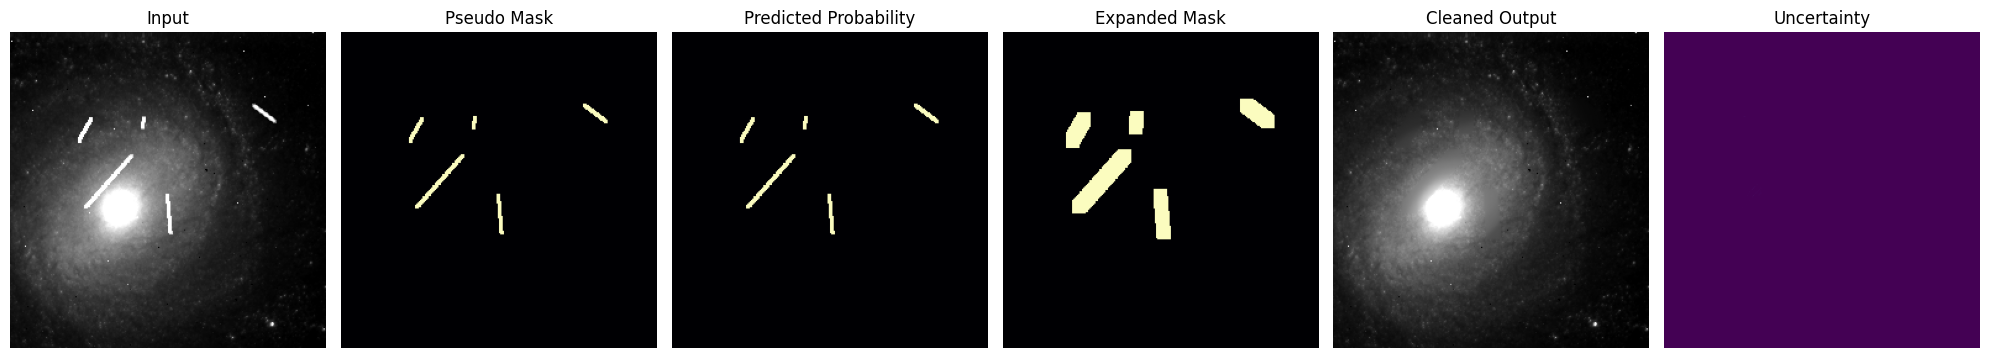

In [39]:
# ================================================================
# Cell 18: Visualize Predictions, Cleaned Images, and Uncertainty
# ================================================================

def visualize_model_results(model, loader, num_samples=4, threshold=0.5, mc_dropout_passes=8):
    batch = next(iter(loader))
    images = batch["image"][:num_samples]
    masks = batch["mask"][:num_samples]
    targets = batch["target"][:num_samples]

    probs, preds, uncertainty = predict_cosmic_ray_mask(
        model,
        images,
        threshold=threshold,
        mc_dropout_passes=mc_dropout_passes,
    )

    n = min(num_samples, images.shape[0])
    fig, axes = plt.subplots(n, 6, figsize=(20, 3.5 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image_np = images[i, 0].numpy()
        true_mask_np = masks[i, 0].numpy()
        prob_np = probs[i, 0].numpy()
        pred_np = preds[i, 0].numpy()
        uncertainty_np = uncertainty[i, 0].numpy()
        expanded_mask_np = expand_cr_mask(pred_np, dilation_size=9, close_size=5).astype(np.float32)
        cleaned_np = clean_with_predicted_mask(
            image_np,
            pred_np,
            median_size=15,
            dilation_size=9,
            inpaint_iterations=8,
        )

        panels = [
            ("Input", image_np, "gray", None),
            ("Pseudo Mask", true_mask_np, "magma", 0),
            ("Predicted Probability", prob_np, "magma", 0),
            ("Expanded Mask", expanded_mask_np, "magma", 0),
            ("Cleaned Output", cleaned_np, "gray", None),
            ("Uncertainty", uncertainty_np, "viridis", 0),
        ]

        for j, (title, data, cmap, vmin) in enumerate(panels):
            axes[i, j].imshow(data, cmap=cmap, vmin=vmin, vmax=1)
            axes[i, j].set_title(title)
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


visualize_model_results(best_model, test_loader, num_samples=4, threshold=0.5, mc_dropout_passes=8)


In [40]:

# ================================================================
# Cell 19: Cross-File / Cross-Telescope-Style Holdout Report
# ================================================================
@torch.no_grad()
def evaluate_full_test_set(
    model,
    test_loader,
    val_loader=None,
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    max_batches=None,
):
    model.eval()

    def safe_binary_metrics(preds, masks):
        preds = preds.float()
        masks = masks.float()

        tp = torch.sum(preds * masks).item()
        fp = torch.sum(preds * (1.0 - masks)).item()
        fn = torch.sum((1.0 - preds) * masks).item()
        tn = torch.sum((1.0 - preds) * (1.0 - masks)).item()

        total = tp + fp + fn + tn
        accuracy = (tp + tn) / total if total > 0 else np.nan

        both_empty = (tp + fp + fn) == 0
        if both_empty:
            return {
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "iou": np.nan,
                "accuracy": 1.0,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
                "empty_case": True,
            }

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

        if np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0:
            f1 = np.nan
        else:
            f1 = 2.0 * precision * recall / (precision + recall)

        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else np.nan

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou,
            "accuracy": accuracy,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "empty_case": False,
        }

    def evaluate_loader(loader, split_name):
        rows = []

        for batch_idx, batch in enumerate(tqdm(loader, desc=f"Evaluating {split_name} thresholds")):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = batch["image"].to(DEVICE).float()
            masks = batch["mask"].to(DEVICE).float()
            paths = batch.get("path", ["unknown"] * images.shape[0])

            probs = torch.sigmoid(model(images))

            for threshold in thresholds:
                preds = (probs >= threshold).float()

                for i, path in enumerate(paths):
                    row_metrics = safe_binary_metrics(preds[i:i+1], masks[i:i+1])

                    rows.append(
                        {
                            "split": split_name,
                            "threshold": threshold,
                            "file": Path(path).name,
                            "cr_fraction_true": float(masks[i].mean().item()),
                            "cr_fraction_pred": float(preds[i].mean().item()),
                            **row_metrics,
                        }
                    )

        patch_df = pd.DataFrame(rows)

        threshold_df = (
            patch_df.groupby("threshold", as_index=False)
            .agg(
                patches=("file", "size"),
                empty_cases=("empty_case", "sum"),
                precision=("precision", lambda x: np.nanmean(x)),
                recall=("recall", lambda x: np.nanmean(x)),
                f1=("f1", lambda x: np.nanmean(x)),
                iou=("iou", lambda x: np.nanmean(x)),
                accuracy=("accuracy", "mean"),
                cr_fraction_true=("cr_fraction_true", "mean"),
                cr_fraction_pred=("cr_fraction_pred", "mean"),
            )
            .sort_values("threshold")
        )

        return patch_df, threshold_df

    if val_loader is not None:
        val_patch_df, val_threshold_df = evaluate_loader(val_loader, "val")
        best_row = val_threshold_df.sort_values("f1", ascending=False, na_position="last").iloc[0]
        optimal_threshold = float(best_row["threshold"])

        print(
            f"Optimal threshold from validation F1: {optimal_threshold:.2f} "
            f"(val F1={best_row['f1']:.4f})"
        )
        display(val_threshold_df)
    else:
        val_patch_df = None
        val_threshold_df = None
        optimal_threshold = None
        print("No validation loader provided, so optimal threshold was not selected from validation F1.")

    test_patch_df, test_threshold_df = evaluate_loader(test_loader, "test")

    print("Test metrics by threshold:")
    display(test_threshold_df)

    if optimal_threshold is not None:
        print("Test metrics at optimal validation threshold:")
        display(test_threshold_df[test_threshold_df["threshold"] == optimal_threshold])

    return {
        "optimal_threshold": optimal_threshold,
        "val_patch_df": val_patch_df,
        "val_threshold_df": val_threshold_df,
        "test_patch_df": test_patch_df,
        "test_threshold_df": test_threshold_df,
    }
full_test_results = evaluate_full_test_set(
    best_model,
    test_loader,
    val_loader=val_loader,
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
)

optimal_threshold = full_test_results["optimal_threshold"]
test_threshold_df = full_test_results["test_threshold_df"]


Evaluating val thresholds:   0%|          | 0/66 [00:00<?, ?it/s]

Optimal threshold from validation F1: 0.70 (val F1=0.9886)


,threshold,patches,empty_cases,precision,recall,f1,iou,accuracy,cr_fraction_true,cr_fraction_pred
0,0.3,264,116,0.890424,0.991269,0.986736,0.883045,0.999894,0.003994,0.004045
1,0.4,264,116,0.891616,0.990999,0.987272,0.883993,0.999900,0.003994,0.004038
2,0.5,264,123,0.937130,0.990846,0.987858,0.928961,0.999907,0.003994,0.004030
3,0.6,264,123,0.938110,0.990650,0.988275,0.929740,0.999911,0.003994,0.004024
4,0.7,264,123,0.938873,0.990555,0.988613,0.930362,0.999915,0.003994,0.004019


Evaluating test thresholds:   0%|          | 0/264 [00:00<?, ?it/s]

Test metrics by threshold:


,threshold,patches,empty_cases,precision,recall,f1,iou,accuracy,cr_fraction_true,cr_fraction_pred
0,0.3,264,113,0.912842,0.993242,0.988307,0.906779,0.999893,0.004697,0.004762
1,0.4,264,113,0.914017,0.993089,0.988879,0.907790,0.999899,0.004697,0.004755
2,0.5,264,113,0.915093,0.992774,0.989305,0.908559,0.999905,0.004697,0.004747
3,0.6,264,113,0.915878,0.992550,0.989612,0.909117,0.999909,0.004697,0.004741
4,0.7,264,114,0.922626,0.992425,0.989899,0.915696,0.999913,0.004697,0.004736


Test metrics at optimal validation threshold:


,threshold,patches,empty_cases,precision,recall,f1,iou,accuracy,cr_fraction_true,cr_fraction_pred
4,0.7,264,114,0.922626,0.992425,0.989899,0.915696,0.999913,0.004697,0.004736


In [42]:
# ================================================================
# Cell 20: Save Final Results, Figures, and Export Model
# ================================================================

RESULTS_DIR = WORKING_DIR / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

history_csv = RESULTS_DIR / "training_history.csv"
benchmark_csv = RESULTS_DIR / "benchmark_results.csv"
per_patch_csv = RESULTS_DIR / "per_patch_results.csv"
per_file_csv = RESULTS_DIR / "per_file_results.csv"
test_threshold_csv = RESULTS_DIR / "test_threshold_results.csv"
val_threshold_csv = RESULTS_DIR / "val_threshold_results.csv"
final_model_path = RESULTS_DIR / "psf_aware_unet_final.pth"

saved_paths = []

if "history_df" in globals():
    history_df.to_csv(history_csv, index=False)
    saved_paths.append(history_csv)
else:
    print("Warning: history_df not found, skipping training_history.csv")

if "benchmark_df" in globals():
    benchmark_df.to_csv(benchmark_csv, index=False)
    saved_paths.append(benchmark_csv)
else:
    print("Warning: benchmark_df not found, skipping benchmark_results.csv")

if "per_patch_df" in globals():
    per_patch_df.to_csv(per_patch_csv, index=False)
    saved_paths.append(per_patch_csv)
else:
    print("Warning: per_patch_df not found, skipping per_patch_results.csv")

if "per_file_df" in globals():
    per_file_df.to_csv(per_file_csv, index=False)
    saved_paths.append(per_file_csv)
else:
    print("Warning: per_file_df not found, skipping per_file_results.csv")

if "full_test_results" in globals():
    if full_test_results.get("test_threshold_df") is not None:
        full_test_results["test_threshold_df"].to_csv(test_threshold_csv, index=False)
        saved_paths.append(test_threshold_csv)

    if full_test_results.get("val_threshold_df") is not None:
        full_test_results["val_threshold_df"].to_csv(val_threshold_csv, index=False)
        saved_paths.append(val_threshold_csv)

threshold = 0.5
if "optimal_threshold" in globals() and optimal_threshold is not None:
    threshold = float(optimal_threshold)
elif "full_test_results" in globals() and full_test_results.get("optimal_threshold") is not None:
    threshold = float(full_test_results["optimal_threshold"])

model_to_save = best_model if "best_model" in globals() else model

save_payload = {
    "model_state_dict": model_to_save.state_dict(),
    "model_name": "PSFAwareUNet",
    "patch_size": PATCH_SIZE,
    "threshold": threshold,
}

if "test_metrics" in globals():
    save_payload["test_metrics"] = test_metrics

if "benchmark_df" in globals():
    save_payload["benchmark"] = benchmark_df.to_dict(orient="records")

if "history_df" in globals():
    save_payload["history"] = history_df.to_dict(orient="records")

if "full_test_results" in globals() and full_test_results.get("test_threshold_df") is not None:
    save_payload["test_threshold_results"] = full_test_results["test_threshold_df"].to_dict(orient="records")

torch.save(save_payload, final_model_path)
saved_paths.append(final_model_path)

summary = {
    "model_path": str(final_model_path),
    "threshold": threshold,
}

if "history_df" in globals() and "val_f1" in history_df.columns:
    summary["best_validation_f1"] = float(history_df["val_f1"].max())

if "test_metrics" in globals():
    summary["final_test_f1"] = float(test_metrics.get("f1", np.nan))
    summary["final_test_precision"] = float(test_metrics.get("precision", np.nan))
    summary["final_test_recall"] = float(test_metrics.get("recall", np.nan))
    summary["final_test_iou"] = float(test_metrics.get("iou", np.nan))

if "benchmark_df" in globals():
    summary["benchmark_csv"] = str(benchmark_csv)

if "history_df" in globals():
    summary["history_csv"] = str(history_csv)

summary_df = pd.DataFrame([summary])
display(summary_df)

print("Saved files:")
for path in saved_paths:
    print(" ", path)


,model_path,threshold,best_validation_f1,final_test_f1,final_test_precision,final_test_recall,final_test_iou,benchmark_csv,history_csv
0,/kaggle/working/model_results/psf_aware_unet_f...,0.7,0.994277,0.9914,0.986518,0.996669,0.983234,/kaggle/working/model_results/benchmark_result...,/kaggle/working/model_results/training_history...


Saved files:
  /kaggle/working/model_results/training_history.csv
  /kaggle/working/model_results/benchmark_results.csv
  /kaggle/working/model_results/test_threshold_results.csv
  /kaggle/working/model_results/val_threshold_results.csv
  /kaggle/working/model_results/psf_aware_unet_final.pth
